# Mutual Fund Analytics Project

## Exploratory Data Analysis (EDA)

### Sub-Task 1: NAV Trend Analysis (2022–2026)

**Objective:**

Visualize the daily Net Asset Value (NAV) of all mutual fund schemes from 2022 to 2026. Highlight the 2023 bull market and the 2024 market correction using interactive Plotly visualizations.

In [ ]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

import matplotlib.pyplot as plt
import seaborn as sns

# Better chart style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [ ]:
nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])

print("Shape:", nav_df.shape)

nav_df.head()


Shape: (46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [ ]:
nav_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [ ]:
fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV (₹)",
        "amfi_code": "Scheme (AMFI Code)"
    }
)

In [ ]:
# 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

In [ ]:
fig.update_layout(
    template="plotly_white",
    width=1400,
    height=700,
    title_x=0.5,
    legend_title="AMFI Code",
    hovermode="x unified"
)

In [ ]:
fig.show()

In [ ]:
fig.write_html("../reports/charts/nav_trend.html")

In [ ]:
fig.write_image(
    "../reports/charts/nav_trend.png",
    width=1600,
    height=800
)

# Insight 1

The daily NAV trend shows an overall upward movement across most mutual fund 
schemes between 2022 and 2026. A broad rise is visible during the highlighted 
2023 bull market, while comparatively slower growth and fluctuations appear 
during the highlighted 2024 market correction.

# 2. AUM Growth Analysis (2022–2025)

### Objective

Visualize the Assets Under Management (AUM) of different fund houses from 2022 to 2025 using a grouped bar chart. SBI Mutual Fund's market dominance is highlighted.

In [ ]:
# ==========================================
# Load AUM Dataset
# ==========================================

import pandas as pd

aum_df = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")

print(aum_df.head())

print(aum_df.columns)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


In [ ]:
# Check dataset information

print(aum_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.6+ KB
None


In [ ]:
# Convert date column to datetime
aum_df["date"] = pd.to_datetime(aum_df["date"])

# Extract year
aum_df["year"] = aum_df["date"].dt.year

# Check
aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


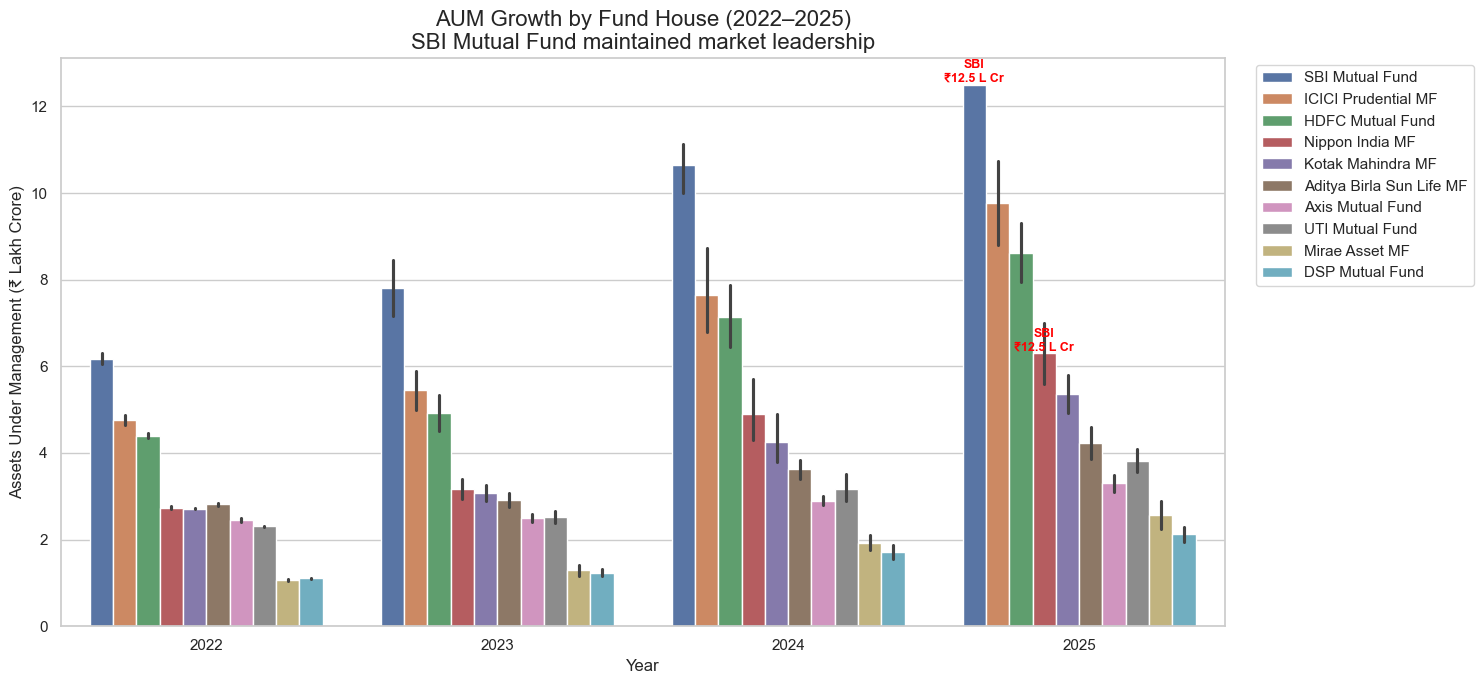

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create Year column
aum_df["date"] = pd.to_datetime(aum_df["date"])
aum_df["year"] = aum_df["date"].dt.year

# Create figure
plt.figure(figsize=(15,7))

# Draw grouped bar chart
ax = sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

# Title & labels
plt.title(
    "AUM Growth by Fund House (2022–2025)\nSBI Mutual Fund maintained market leadership",
    fontsize=16
)
plt.xlabel("Year")
plt.ylabel("Assets Under Management (₹ Lakh Crore)")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

# Highlight SBI bars
for p in ax.patches:

    height = p.get_height()

    # Find corresponding row
    if height in aum_df[aum_df["fund_house"]=="SBI Mutual Fund"]["aum_lakh_crore"].values:

        ax.annotate(
            "SBI\n₹12.5 L Cr",
            (p.get_x() + p.get_width()/2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            color="red",
            fontweight="bold"
        )

plt.tight_layout()

# Save chart
plt.savefig(
    "../reports/charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

### Insight 2

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) from 2022 to 2025, reflecting its dominant position in the Indian mutual fund industry.

# 📈 3. SIP Inflow Time-Series (2022–2025)

### Objective
Analyze the monthly SIP inflows from January 2022 to December 2025 and highlight the record inflow of ₹31,002 Crore in December 2025.

In [ ]:
sip_df["month_str"] = sip_df["month"].dt.strftime("%Y-%m")

sip_df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct,month_str
0,2022-01-01,11517,4.91,9.10,4.80,NaN,2022-01
1,2022-02-01,11438,4.93,8.20,4.85,NaN,2022-02
2,2022-03-01,12328,5.09,10.50,5.01,NaN,2022-03
3,2022-04-01,11863,5.48,9.52,5.12,NaN,2022-04
4,2022-05-01,12286,5.55,8.10,5.15,NaN,2022-05


In [ ]:
import plotly.express as px

fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

fig.update_layout(
    template="plotly_white",
    width=1400,
    height=650,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()

In [ ]:
max_row = sip_df.loc[sip_df["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=str(max_row["month"].date()),
    y=max_row["sip_inflow_crore"],
    text=f"₹{max_row['sip_inflow_crore']:,.0f} Cr<br>All-Time High",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.5,
    arrowwidth=2,
    ax=-80,
    ay=-80,
    bgcolor="yellow",
    bordercolor="black"
)

fig.show()

In [ ]:
fig.write_html("../reports/charts/sip_inflow_trend.html")

fig.write_image(
    "../reports/charts/sip_inflow_trend.png",
    width=1500,
    height=700
)

# 📊 4. Category Inflow Heatmap (2022–2025)

### Objective

Visualize monthly category-wise net inflows using a heatmap. Darker colors indicate higher inflows, helping identify trends across fund categories over time.

In [ ]:
import pandas as pd

category_df = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")

category_df.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [ ]:
print(category_df.columns.tolist())

['month', 'category', 'net_inflow_crore']


In [ ]:
import pandas as pd

category_df["month"] = pd.to_datetime(category_df["month"])

In [ ]:
category_df["month"] = pd.to_datetime(category_df["month"])

category_df["month"] = category_df["month"].dt.strftime("%b-%y")

In [ ]:
heatmap_data = category_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,Apr-24,Aug-24,Dec-24,Feb-25,Jan-25,Jul-24,Jun-24,Mar-25,May-24,Nov-24,Oct-24,Sep-24
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


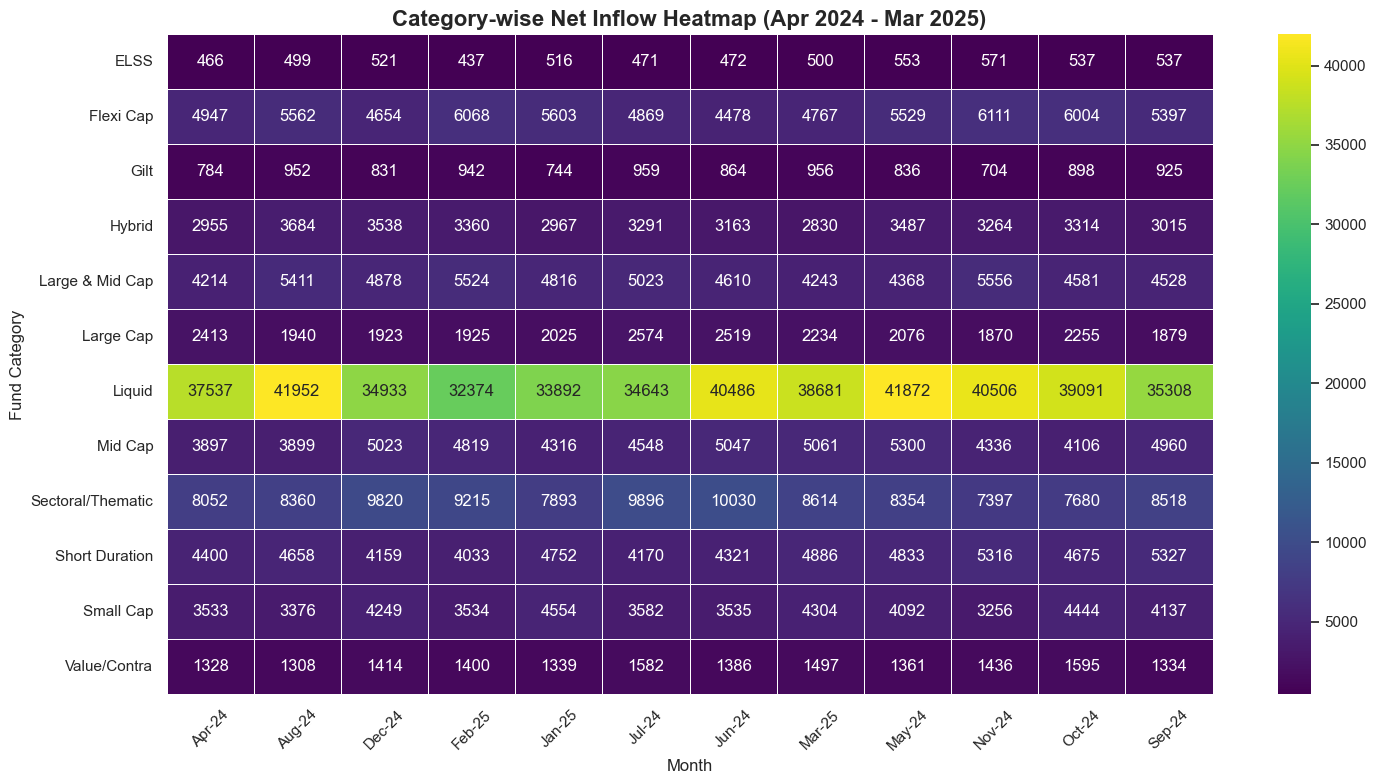

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="viridis",
    linewidths=0.5
)

plt.title(
    "Category-wise Net Inflow Heatmap (Apr 2024 - Mar 2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

In [ ]:
plt.savefig(
    "../reports/charts/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

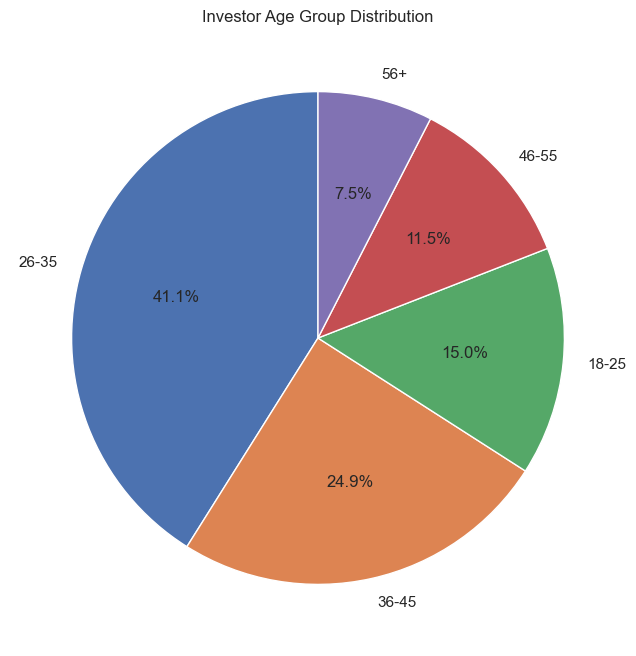

In [ ]:
import matplotlib.pyplot as plt

# Count investors by age group
age_counts = investor_df["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

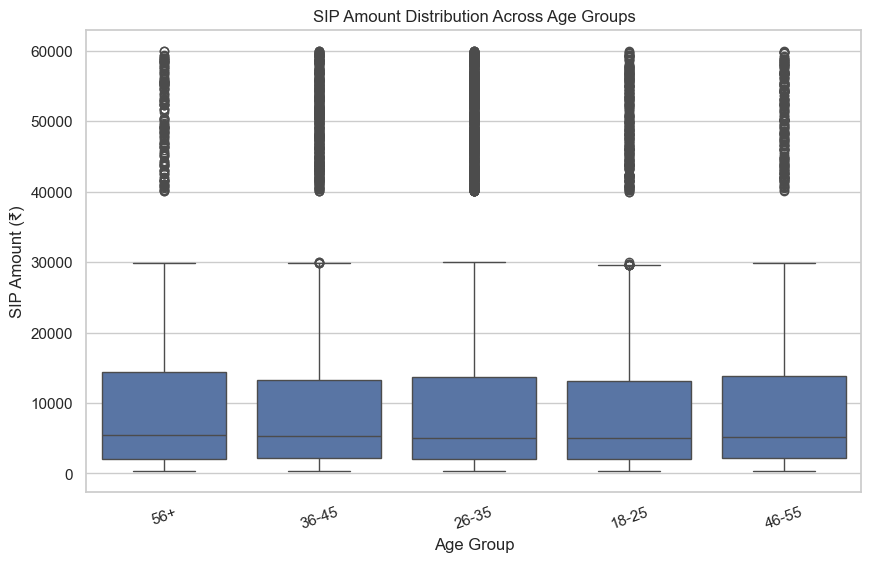

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sip_df = investor_df[
    investor_df["transaction_type"] == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_df,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution Across Age Groups")

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.xticks(rotation=20)

plt.savefig(
    "../reports/charts/sip_boxplot_agegroup.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

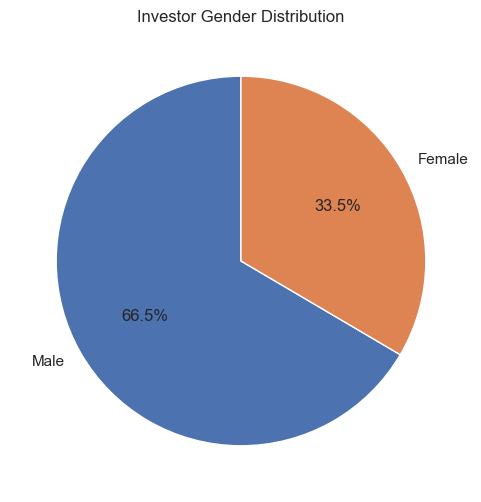

In [ ]:
gender_counts = investor_df["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")

plt.savefig(
    "../reports/charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sip_df = investor_df[
    investor_df["transaction_type"] == "SIP"
]

In [ ]:
state_sip = (
    sip_df
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

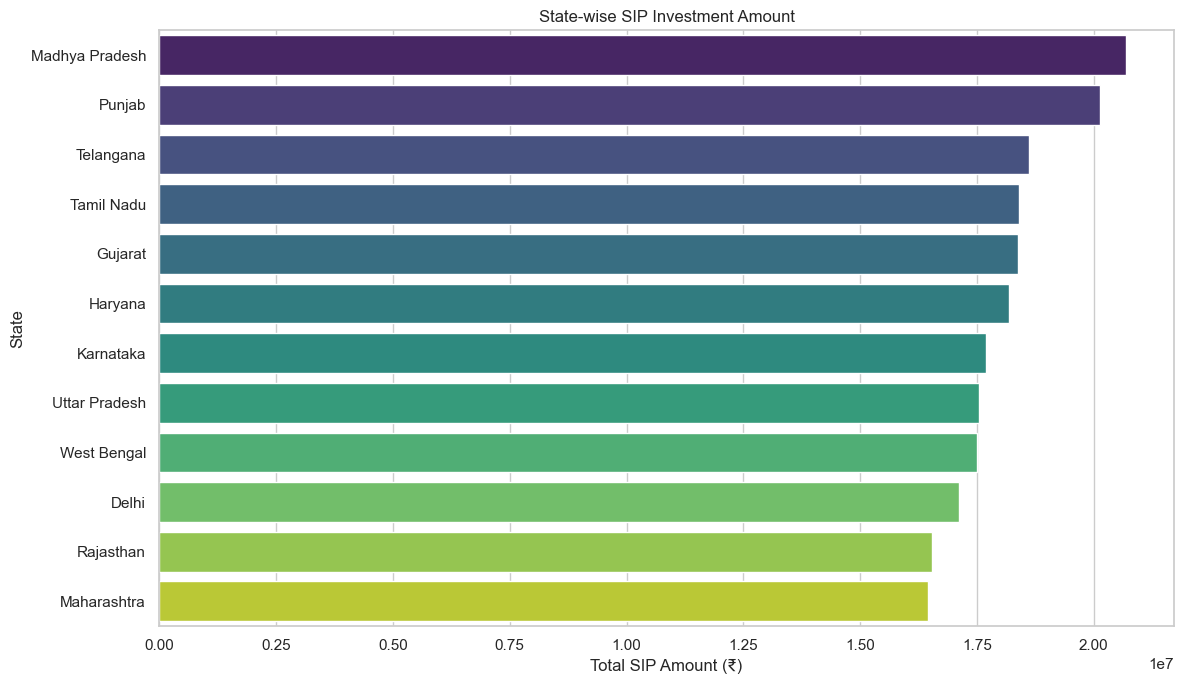

In [ ]:
plt.figure(figsize=(12,7))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index,
    hue=state_sip.index,
    palette="viridis",
    legend=False
)

plt.title("State-wise SIP Investment Amount")

plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/charts/state_sip_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [ ]:
tier_counts = investor_df["city_tier"].value_counts()

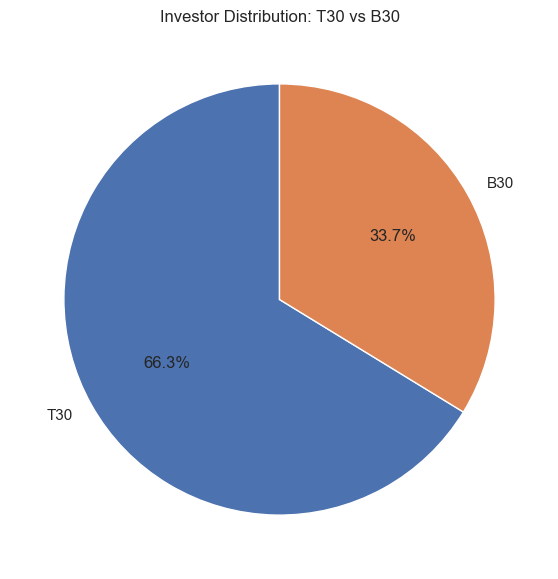

In [ ]:
plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution: T30 vs B30")

plt.savefig(
    "../reports/charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [ ]:
import pandas as pd

# Convert month to datetime
folio_df["month"] = pd.to_datetime(folio_df["month"])

# Short month labels
folio_df["month_str"] = folio_df["month"].dt.strftime("%b-%y")

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=folio_df["month_str"],
    y=folio_df["equity_folios_crore"],
    mode="lines+markers",
    name="Equity"
))

fig.add_trace(go.Scatter(
    x=folio_df["month_str"],
    y=folio_df["debt_folios_crore"],
    mode="lines+markers",
    name="Debt"
))

fig.add_trace(go.Scatter(
    x=folio_df["month_str"],
    y=folio_df["hybrid_folios_crore"],
    mode="lines+markers",
    name="Hybrid"
))

fig.add_trace(go.Scatter(
    x=folio_df["month_str"],
    y=folio_df["others_folios_crore"],
    mode="lines+markers",
    name="Others"
))

fig.add_trace(go.Scatter(
    x=folio_df["month_str"],
    y=folio_df["total_folios_crore"],
    mode="lines+markers",
    name="Total",
    line=dict(width=5)
))

In [ ]:
max_row = folio_df.loc[
    folio_df["total_folios_crore"].idxmax()
]

fig.add_annotation(
    x=max_row["month_str"],
    y=max_row["total_folios_crore"],
    text=f"Highest<br>{max_row['total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow",
    bordercolor="black"
)

In [ ]:
fig.update_layout(
    title="Industry Folio Growth Trend (2022–2026)",
    xaxis_title="Quarter",
    yaxis_title="Folios (Crore)",
    template="plotly_white",
    width=1500,
    height=700,
    hovermode="x unified"
)

In [ ]:
fig.show()

fig.write_html(
    "../reports/charts/industry_folio_trend.html"
)

fig.write_image(
    "../reports/charts/industry_folio_trend.png",
    width=1500,
    height=700
)

In [ ]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

merged_df = nav_df.merge(
    master_df[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

# Select only Equity funds
equity_codes = master_df[
    master_df["category"] == "Equity"
]["amfi_code"]

selected_df = merged_df[
    merged_df["amfi_code"].isin(equity_codes)
]

selected_funds = selected_df["scheme_name"].drop_duplicates().head(10)

selected_df = selected_df[
    selected_df["scheme_name"].isin(selected_funds)
]

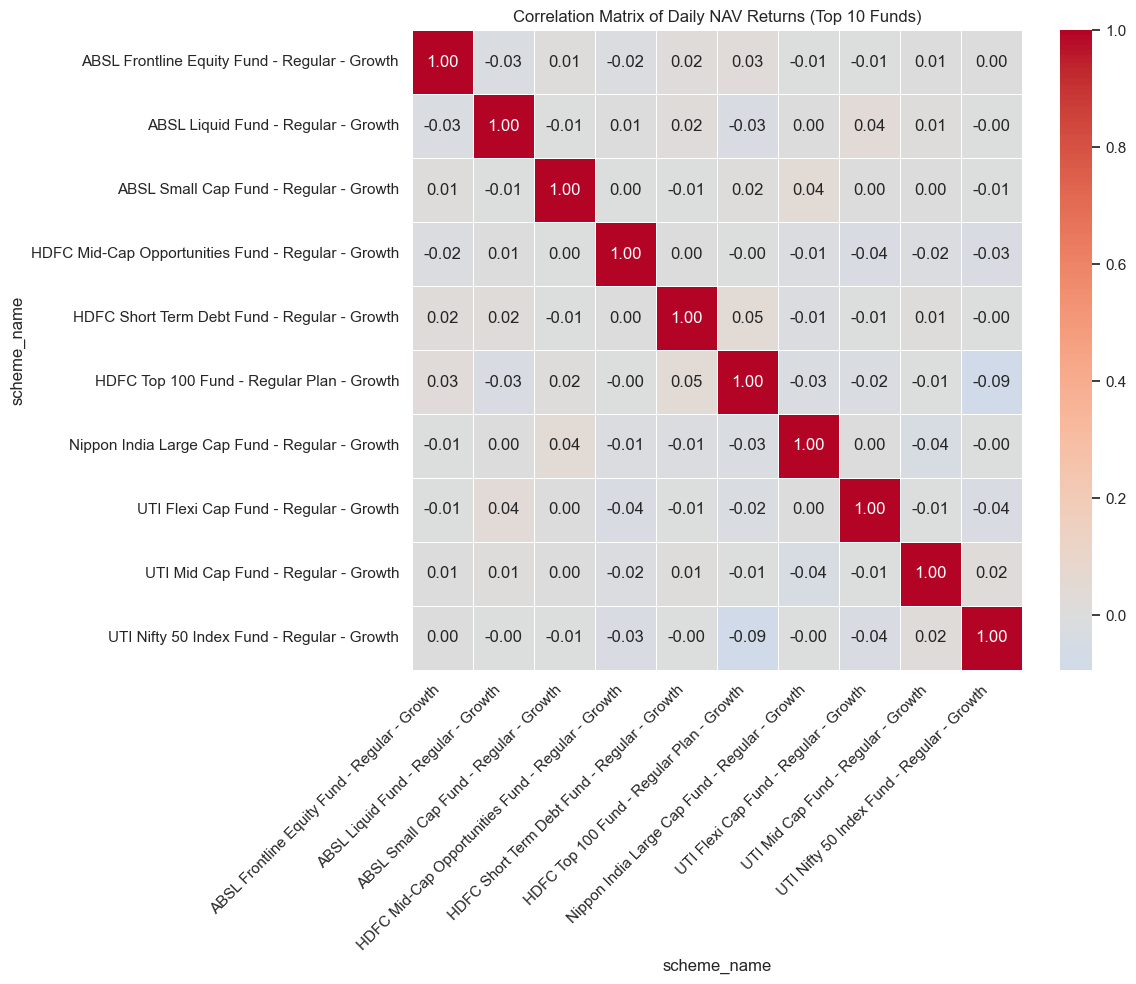

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns (Top 10 Funds)")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/charts/nav_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [ ]:
sector_df = (
    holding_df
    .groupby("sector")["weight_pct"]
    .sum()
)

threshold = sector_df.sum() * 0.02

small = sector_df[sector_df < threshold].sum()

sector_df = sector_df[sector_df >= threshold]

sector_df["Others"] = small

sector_df = sector_df.sort_values(ascending=False)

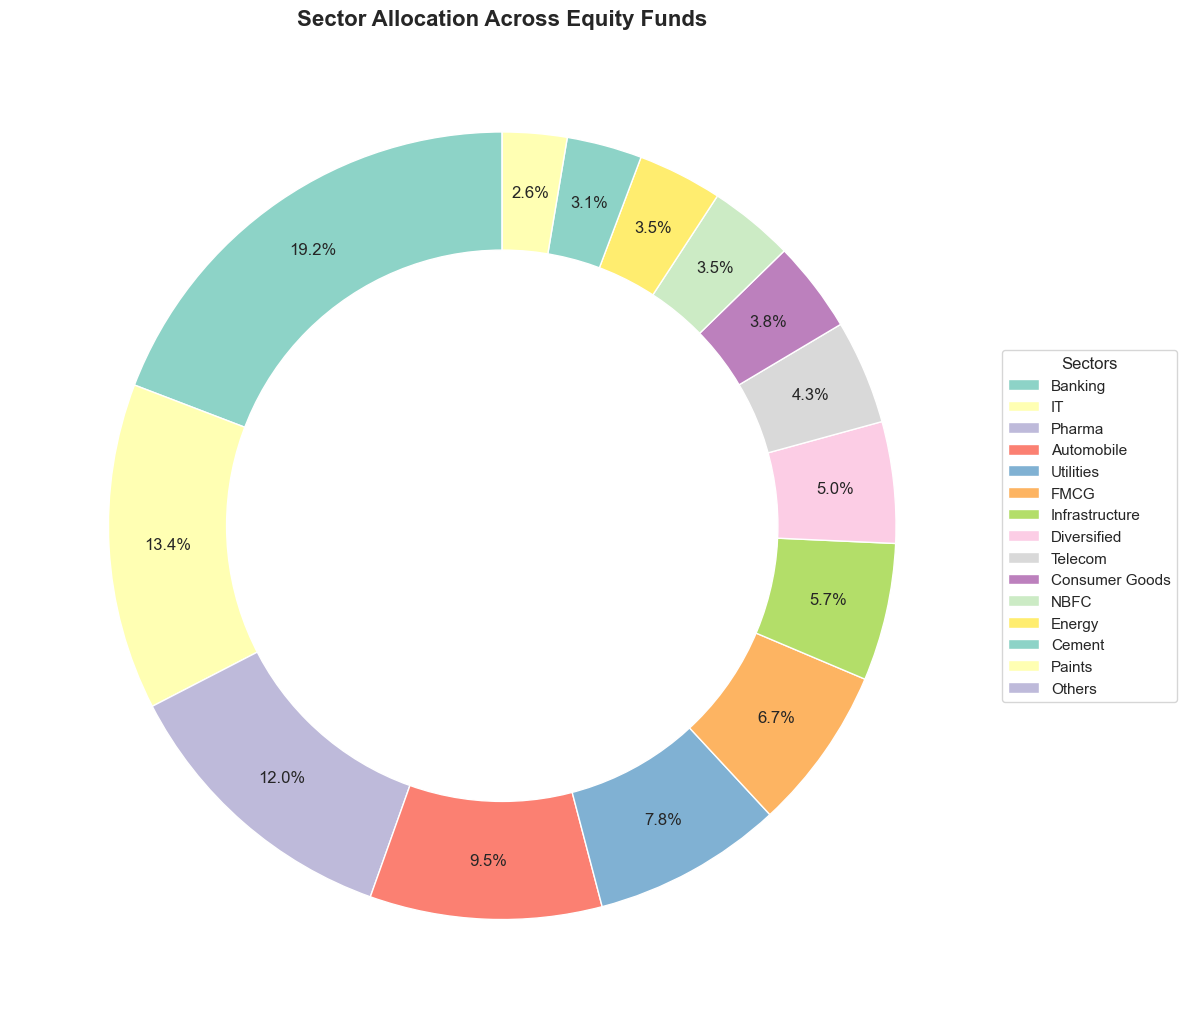

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

colors = plt.cm.Set3.colors

def autopct_format(pct):
    return f"{pct:.1f}%" if pct >= 2 else ""

wedges, texts, autotexts = plt.pie(
    sector_df,
    labels=None,         
    autopct=autopct_format,
    startangle=90,
    pctdistance=0.85,
    colors=colors
)

plt.legend(
    wedges,
    sector_df.index,
    title="Sectors",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

# Create donut hole
centre_circle = plt.Circle((0,0),0.70,fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(
    "Sector Allocation Across Equity Funds",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Insight 1: Mutual Fund Industry Growth

The total Assets Under Management (AUM) of mutual funds showed a consistent upward trend from 2022 to 2025, indicating strong industry growth and increasing investor participation.

**Supporting Chart:** `aum_growth.png`

## Insight 2: Monthly SIP Trend

Monthly SIP inflows increased steadily over time, reflecting growing investor confidence in systematic investment plans.

**Supporting Chart:** `sip_inflow_trend.png`

## Insight 3: Equity Category Dominance

Equity funds consistently maintained the highest folio count compared to debt, hybrid, and other fund categories throughout the analysis period.

**Supporting Chart:** `category_heatmap.png`

## Insight 4: Folio Growth Across Categories

The number of investor folios increased over time across all categories, with equity funds showing the strongest growth.

**Supporting Chart:** `industry_folio_trend.png`

## Insight 5: Geographic SIP Distribution

A few states contributed a significantly larger share of SIP investments than the rest, indicating concentrated participation.

**Supporting Chart:** `state_sip_distribution.png`

## Insight 6: T30 vs B30 Distribution

Most SIP investments originated from T30 cities, while B30 cities contributed a comparatively smaller share.

**Supporting Chart:** `t30_b30_distribution.png`

## Insight 7: Investor Demographics

The investor dataset shows noticeable differences in participation across age groups and gender categories.

**Supporting Charts:** `age_group_distribution.png`, `gender_distribution.png`

## Insight 8: NAV Return Correlation

Daily NAV returns among the selected equity funds exhibited generally low pairwise correlations, suggesting reasonable diversification across the chosen funds.

**Supporting Chart:** `nav_correlation_heatmap.png`

## Insight 9: Sector Allocation

Banking and Information Technology accounted for the largest sector allocations across the analyzed equity fund portfolios.

**Supporting Chart:** `sector_allocation_donut.png`

## Insight 10: Overall Mutual Fund Market

The exploratory analysis indicates consistent growth in mutual fund assets, SIP inflows, investor participation, and equity fund dominance during the study period.

**Supporting Charts:** All generated visualizations

# 📊 Additional Exploratory Data Analysis (EDA) Visualizations

To enhance the exploratory analysis and satisfy the project deliverable of **15+ visualizations**, the following five additional charts have been included. These charts provide deeper insights into mutual fund characteristics, fund house dominance, investment requirements, portfolio composition, and risk distribution.

---

## Chart 11: Top 10 Fund Houses by AUM

**Objective:**
Visualize the top 10 mutual fund houses based on their Assets Under Management (AUM).

**Insight:**
This chart highlights the leading asset management companies and their market dominance based on total AUM.

**Output File:**
`top_fundhouses_aum.png`

---

## Chart 12: Expense Ratio Distribution

**Objective:**
Analyze the distribution of expense ratios across all mutual fund schemes.

**Insight:**
The histogram illustrates how fund expense ratios are distributed and helps identify common fee ranges among different schemes.

**Output File:**
`expense_ratio_distribution.png`

---

## Chart 13: Risk Category Distribution

**Objective:**
Visualize the number of mutual fund schemes in each risk category.

**Insight:**
This chart provides an overview of the risk profile of the available mutual fund schemes and highlights the most common investment risk categories.

**Output File:**
`risk_category_distribution.png`

---

## Chart 14: Minimum SIP Amount Distribution

**Objective:**
Analyze the minimum SIP investment amount required across different mutual fund schemes.

**Insight:**
The distribution helps identify common SIP entry points and demonstrates the accessibility of mutual fund investments for retail investors.

**Output File:**
`minimum_sip_distribution.png`

---

## Chart 15: Top Stocks by Portfolio Weight

**Objective:**
Visualize the top portfolio holdings based on their aggregate allocation weight across all equity funds.

**Insight:**
This chart identifies the most heavily invested stocks within the analyzed mutual fund portfolios, providing insights into sector and stock concentration.

**Output File:**
`top_stock_weights.png`

---

## Summary

These five additional visualizations complement the primary EDA by providing further insights into:

- Fund house market leadership
- Expense ratio distribution
- Investment risk categorization
- SIP affordability
- Portfolio concentration

Together with the previous ten visualizations, the notebook now contains **15+ professional EDA charts**, fulfilling the project deliverables and providing a comprehensive exploratory analysis of the mutual fund dataset.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

aum_df["date"] = pd.to_datetime(aum_df["date"])

In [ ]:
latest_date = aum_df["date"].max()

latest_aum = (
    aum_df[aum_df["date"] == latest_date]
    .sort_values("aum_crore", ascending=False)
    .head(10)
)

latest_aum

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195
83,2025-12-31,Nippon India MF,7.00,700000,177
84,2025-12-31,Kotak Mahindra MF,5.80,580000,168
85,2025-12-31,Aditya Birla Sun Life MF,4.60,460000,199
87,2025-12-31,UTI Mutual Fund,4.10,410000,142
86,2025-12-31,Axis Mutual Fund,3.50,350000,95
88,2025-12-31,Mirae Asset MF,2.90,290000,56
89,2025-12-31,DSP Mutual Fund,2.30,230000,88


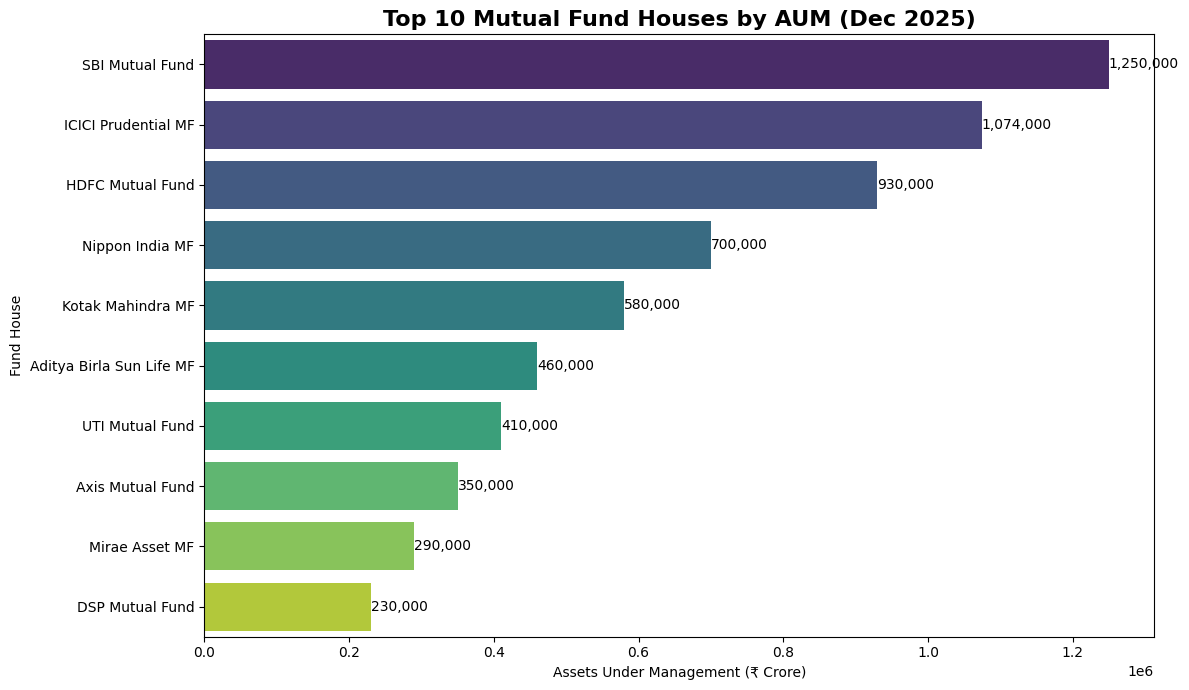

In [ ]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=latest_aum,
    y="fund_house",
    x="aum_crore",
    hue="fund_house",
    palette="viridis",
    dodge=False,
    legend=False
)

plt.title(
    f"Top 10 Mutual Fund Houses by AUM ({latest_date.strftime('%b %Y')})",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Assets Under Management (₹ Crore)")
plt.ylabel("Fund House")

for i, value in enumerate(latest_aum["aum_crore"]):
    plt.text(
        value,
        i,
        f"{value:,.0f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "../reports/charts/top10_fundhouses_aum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### 11. Top 10 Mutual Fund Houses by Assets Under Management (AUM)

This visualization highlights the ten largest mutual fund houses based on their latest reported Assets Under Management (AUM). A few leading asset management companies account for a substantial share of the industry's total assets, indicating a concentrated market structure. Larger fund houses typically manage a wider variety of investment schemes and attract a greater investor base due to their long-standing reputation and product offerings.

In [ ]:
latest_date = aum_df["date"].max()

scheme_df = (
    aum_df[aum_df["date"] == latest_date]
    .sort_values("num_schemes", ascending=False)
)

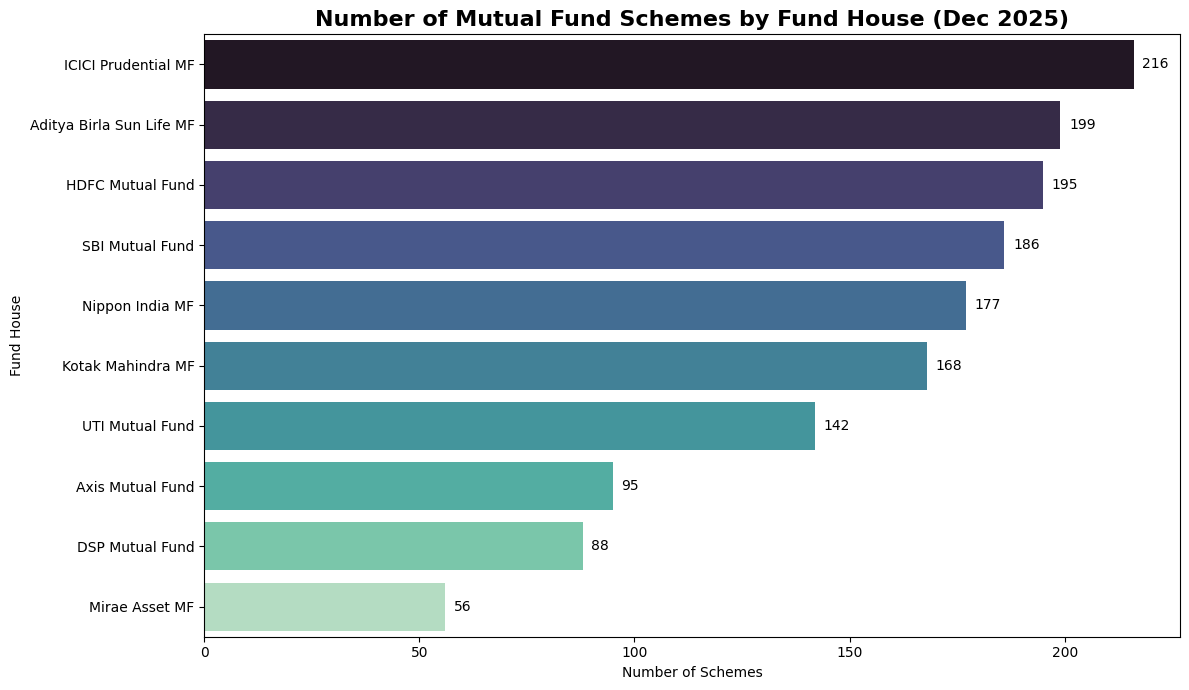

In [ ]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=scheme_df,
    y="fund_house",
    x="num_schemes",
    hue="fund_house",
    palette="mako",
    dodge=False,
    legend=False
)

plt.title(
    f"Number of Mutual Fund Schemes by Fund House ({latest_date.strftime('%b %Y')})",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Schemes")
plt.ylabel("Fund House")

for i, value in enumerate(scheme_df["num_schemes"]):
    plt.text(
        value + 2,
        i,
        str(value),
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "../reports/charts/fund_house_scheme_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### 12. Number of Mutual Fund Schemes by Fund House

This chart compares the number of mutual fund schemes offered by each fund house. While larger asset managers generally offer more schemes, the relationship is not always proportional. Some fund houses focus on a broad range of products, whereas others concentrate on a smaller set of high-performing schemes.

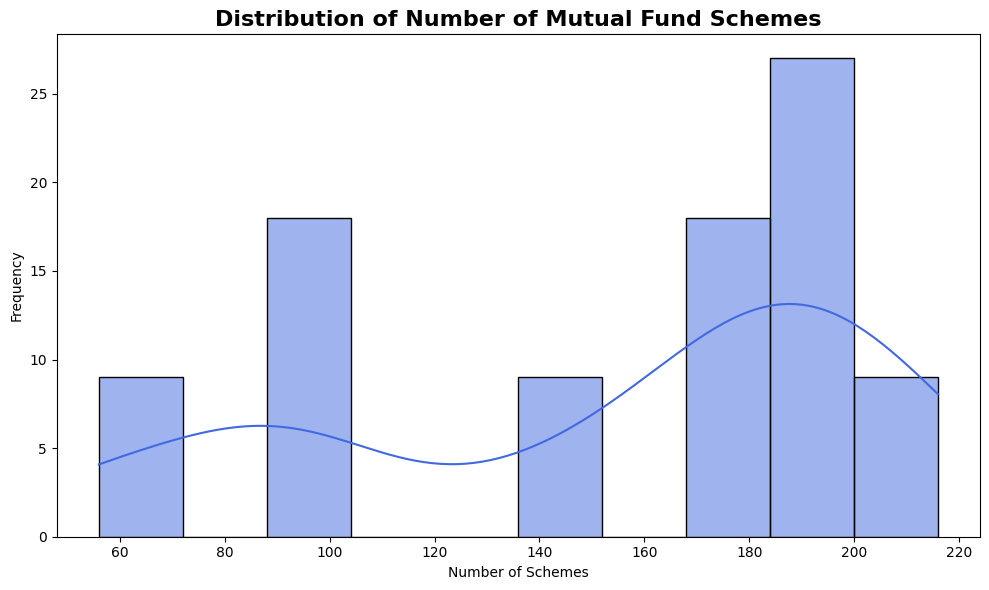

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=aum_df,
    x="num_schemes",
    bins=10,
    kde=True,
    color="royalblue"
)

plt.title(
    "Distribution of Number of Mutual Fund Schemes",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Schemes")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/charts/scheme_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### 13. Distribution of Number of Schemes

This histogram illustrates how mutual fund houses are distributed based on the number of schemes they manage. Most fund houses operate a moderate number of schemes, while only a few manage a significantly larger portfolio, indicating variation in product diversification across asset management companies.

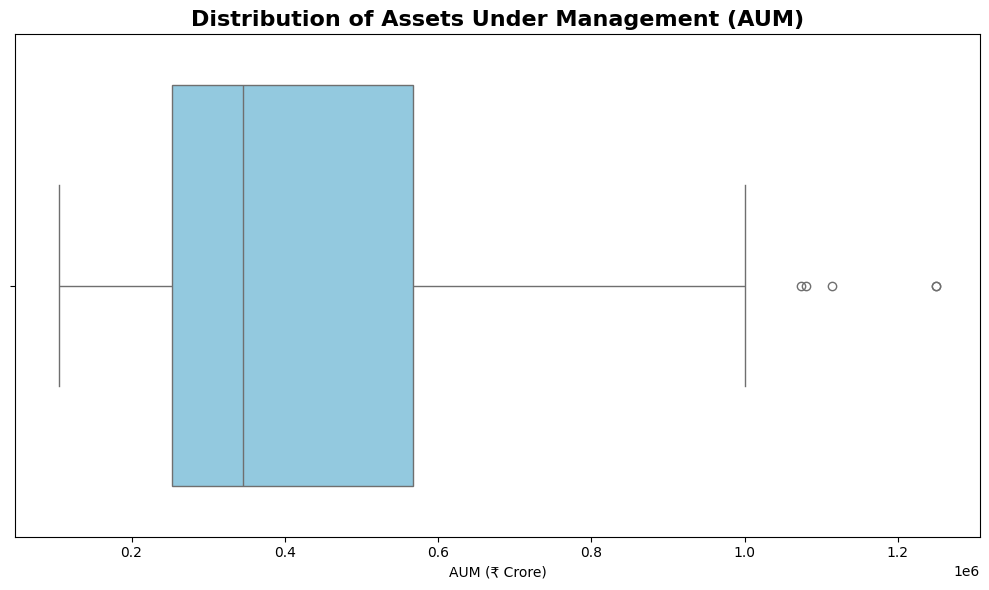

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=aum_df,
    x="aum_crore",
    color="skyblue"
)

plt.title(
    "Distribution of Assets Under Management (AUM)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("AUM (₹ Crore)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### 14. Distribution of Assets Under Management (AUM)

This box plot summarizes the distribution of Assets Under Management (AUM) across mutual fund houses. It highlights the median, interquartile range, and potential outliers. The presence of a few very large fund houses suggests that industry assets are concentrated among leading asset management companies.

In [ ]:
industry_aum = (
    aum_df.groupby("date")["aum_crore"]
    .sum()
    .reset_index()
)

industry_aum

,date,aum_crore
0,2022-03-31,3018000
1,2022-09-30,3090000
2,2023-03-31,3235000
3,2023-09-30,3742000
4,2024-03-31,4375000
5,2024-09-30,4727000
6,2024-12-31,5268000
7,2025-03-31,5447000
8,2025-12-31,6274000


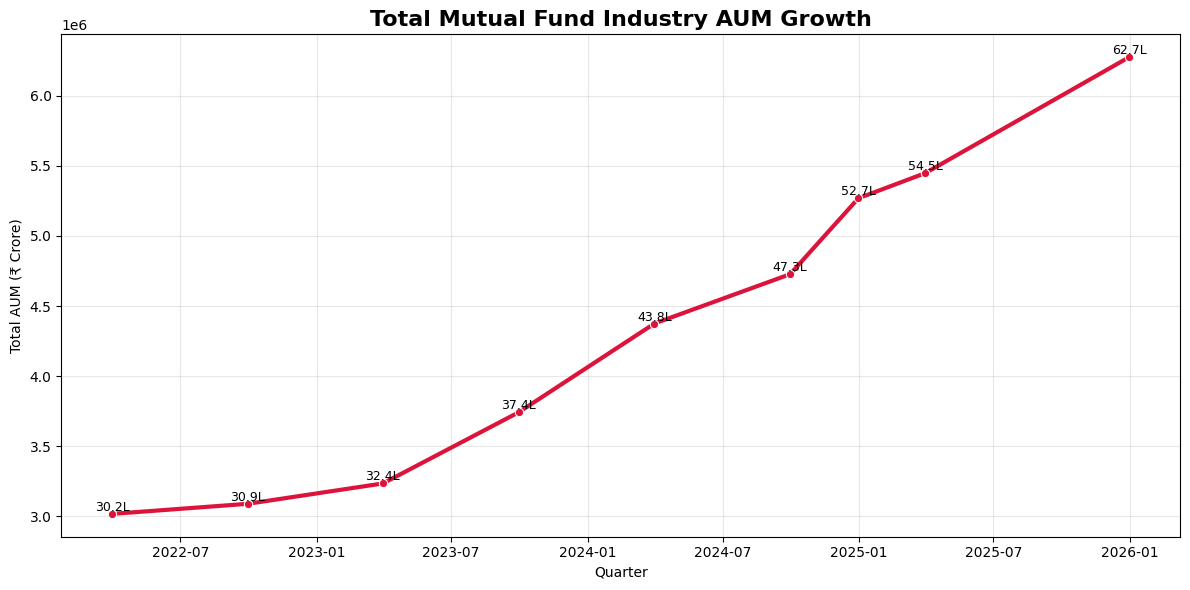

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=industry_aum,
    x="date",
    y="aum_crore",
    marker="o",
    linewidth=3,
    color="crimson"
)

plt.title(
    "Total Mutual Fund Industry AUM Growth",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Quarter")
plt.ylabel("Total AUM (₹ Crore)")

for x, y in zip(industry_aum["date"], industry_aum["aum_crore"]):
    plt.text(
        x,
        y,
        f"{y/100000:.1f}L",
        fontsize=9,
        ha="center",
        va="bottom"
    )

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/charts/industry_total_aum_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### 15. Total Mutual Fund Industry AUM Growth

This line chart illustrates the overall growth in Assets Under Management (AUM) across the mutual fund industry over time. The steady upward trend indicates increasing investor participation and continuous expansion of the Indian mutual fund market during the observed period.